In [1]:
import pandas as pd
import numpy as np
import re
from datetime import datetime


import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
prev_years_df = pd.read_csv("ice_removals_fy12-23ytd 2.csv", sep="|")

/var/folders/lx/9nt__35s79d_0j0wcwz1yrx80000gn/T/ipykernel_45709/4233690993.py:1: DtypeWarning: Columns (0: case_close_date, 1: apprehension_method_code, 2: processing_disposition_code, 3: arrest_date, 4: processing_disposition, 5: removal_date, 6: case_closed_date) have mixed types. Specify dtype option on import or set low_memory=False.
  prev_years_df = pd.read_csv("ice_removals_fy12-23ytd 2.csv", sep="|")


In [3]:
prev_years_df["departed_date"] = pd.to_datetime(
    prev_years_df["departed_date"],
    format="%m/%d/%Y",   # optional but faster if consistent
    errors="coerce"
)

# Create a NEW column with just the year
prev_years_df["departed_year"] = (
    prev_years_df["departed_date"]
    .dt.year
    .astype("Int64")     # keeps missing values clean
)

prev_years_df_modif = prev_years_df[["departed_year", "citizenship_country"]]
print(prev_years_df_modif.head())


   departed_year citizenship_country
0           2012              MEXICO
1           2011              MEXICO
2           2012              MEXICO
3           2012           GUATEMALA
4           2012              MEXICO


In [4]:
df = IR_df = pd.read_csv("ICERemovalsdata.csv",
                        encoding='latin-1')

In [5]:
ctdc = pd.read_csv("CTDC_global_synthetic_data_v2025.csv")

In [6]:
print(df.head())
#print(ctdc.head())

  Arresting Agency          Criminality Area of Responsibility (AOR)  \
0              CBP  Criminal Conviction                      Atlanta   
1              CBP  Criminal Conviction                      Atlanta   
2              CBP  Criminal Conviction                      Atlanta   
3              CBP  Criminal Conviction                      Atlanta   
4              CBP  Criminal Conviction                      Atlanta   

  Country of Citizenship  Fiscal Year  Fiscal Quarter  Fiscal Month  \
0            EL SALVADOR         2024               2             4   
1              GUATEMALA         2021               1             1   
2              GUATEMALA         2021               1             2   
3              GUATEMALA         2023               1             2   
4              GUATEMALA         2023               2             4   

  Month-Year  Removals  
0   Jan 2024        10  
1   Oct 2020        25  
2   Nov 2020        18  
3   Nov 2022        13  
4   Jan 2023   

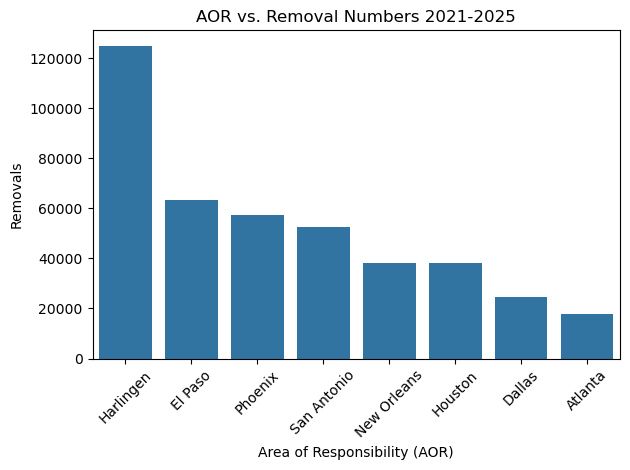

In [7]:
country_totals = df.groupby('Area of Responsibility (AOR)')['Removals'].sum().reset_index()
country_totals = country_totals.sort_values('Removals', ascending=False).head(8)

sns.barplot(data=country_totals, x='Area of Responsibility (AOR)', y='Removals')
plt.title('AOR vs. Removal Numbers 2021-2025')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
print(country_totals)

   Area of Responsibility (AOR)  Removals
10                    Harlingen    124986
8                       El Paso     63563
18                      Phoenix     57576
20                  San Antonio     52586
14                  New Orleans     38159
11                      Houston     38037
5                        Dallas     24407
0                       Atlanta     17635


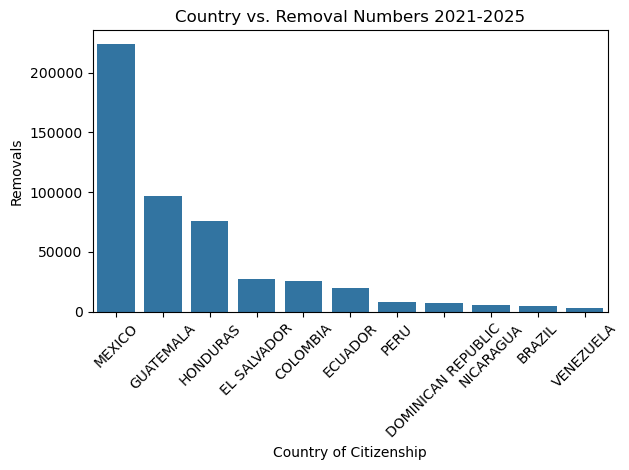

In [9]:
country_totals = df.groupby('Country of Citizenship')['Removals'].sum().reset_index()
country_totals = country_totals.sort_values('Removals', ascending=False).head(11)

sns.barplot(data=country_totals, x='Country of Citizenship', y='Removals')
plt.title('Country vs. Removal Numbers 2021-2025')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
df_TOPAOR = df[df['Area of Responsibility (AOR)'].isin(country_totals['Area of Responsibility (AOR)'])]
print(df_TOPAOR.head())

KeyError: 'Area of Responsibility (AOR)'

In [ ]:
#Line Column for Change By Year
sns.lineplot(data=df_TOPAOR, x='Month-Year', y='Removals', hue='Area of Responsibility (AOR)')
plt.title('Removals Over Time by AOR')
plt.xlabel('Month-Year')
plt.xticks(rotation=45)
plt.ylabel('Removals')
plt.tight_layout()
plt.show()

In [10]:
prev_country_year_counts = (
    prev_years_df_modif
        .groupby(["departed_year", "citizenship_country"])
        .size()
        .reset_index(name="frequency")
)

print(prev_country_year_counts.head())

   departed_year citizenship_country  frequency
0           2010             ALBANIA          1
1           2010           ARGENTINA          3
2           2010             ARMENIA          2
3           2010             BAHAMAS          1
4           2010          BANGLADESH          4


In [11]:
iso = pd.read_csv("ISO_codes.csv")
iso = iso[["name", "alpha-3"]]

anti_join = prev_country_year_counts[
    ~prev_country_year_counts["citizenship_country"].str.lower().isin(
        iso["name"].str.lower()
    )
]
print(anti_join["citizenship_country"].unique())

iso_mapping = dict(zip(iso["name"].str.lower(), iso["name"]))

manual_mappings = {
'bolivia': 'Bolivia, Plurinational State of',
    'burma': 'Myanmar',
    'china, peoples republic of': 'China',
    'iran': 'Iran, Islamic Republic of',
    'korea': 'Korea, Republic of',
    'laos': 'Lao People\'s Democratic Republic',
    'netherlands': 'Netherlands, Kingdom of the',
    'russia': 'Russian Federation',
    'serbia and montenegro': 'Serbia',
    'south korea': 'Korea, Republic of',
    'syria': 'Syrian Arab Republic',
    'taiwan': 'Taiwan, Province of China',
    'turkey': 'Türkiye',
    'united kingdom': 'United Kingdom of Great Britain and Northern Ireland',
    'venezuela': 'Venezuela, Bolivarian Republic of',
    'vietnam': 'Viet Nam',
    'yugoslavia': 'Serbia',
    'antigua-barbuda': 'Antigua and Barbuda',
    'bosnia-herzegovina': 'Bosnia and Herzegovina',
    'british virgin islands': 'Virgin Islands (British)',
    'cape verde': 'Cabo Verde',
    'czech republic': 'Czechia',
    'czechoslovakia': 'Czechia',
    'dem rep of the congo': 'Congo, Democratic Republic of the',
    'ivory coast': 'Côte d\'Ivoire',
    'macedonia': 'North Macedonia',
    'moldova': 'Moldova, Republic of',
    'st. kitts-nevis': 'Saint Kitts and Nevis',
    'st. lucia': 'Saint Lucia',
    'st. vincent-grenadines': 'Saint Vincent and the Grenadines',
    'tanzania': 'Tanzania, United Republic of',
    'netherlands antilles': 'Curaçao',
    'ussr': 'Russian Federation',
    'swaziland': 'Eswatini',
    'macau': 'Macao',
    'north korea': 'Korea, Democratic People\'s Republic of'
}

def map_country(country):
    country_lower = country.lower()
    if country_lower in manual_mappings:
        return manual_mappings[country_lower]
    return iso_mapping.get(country_lower, country)

prev_country_year_counts["citizenship_country"] = prev_country_year_counts["citizenship_country"].apply(map_country)

anti_join = prev_country_year_counts[
    ~prev_country_year_counts["citizenship_country"].str.lower().isin(
        iso["name"].str.lower()
    )
]
print(anti_join["citizenship_country"].unique())

print(prev_country_year_counts.head())

prev_country_year_counts = prev_country_year_counts.merge(
    iso[["name", "alpha-3"]],
    left_on="citizenship_country",
    right_on="name",
    how="left"
)
prev_country_year_counts = prev_country_year_counts.drop(columns=["name"])
print(prev_country_year_counts.head())


<StringArray>
[                   'BOLIVIA',                      'BURMA',
 'CHINA, PEOPLES REPUBLIC OF',                       'IRAN',
                      'KOREA',                       'LAOS',
                'NETHERLANDS',                     'RUSSIA',
      'SERBIA AND MONTENEGRO',                'SOUTH KOREA',
                      'SYRIA',                     'TAIWAN',
                     'TURKEY',             'UNITED KINGDOM',
                  'VENEZUELA',                    'VIETNAM',
                 'YUGOSLAVIA',            'ANTIGUA-BARBUDA',
         'BOSNIA-HERZEGOVINA',     'BRITISH VIRGIN ISLANDS',
                 'CAPE VERDE',             'CZECH REPUBLIC',
             'CZECHOSLOVAKIA',       'DEM REP OF THE CONGO',
                'IVORY COAST',                     'KOSOVO',
                  'MACEDONIA',                    'MOLDOVA',
            'ST. KITTS-NEVIS',                  'ST. LUCIA',
     'ST. VINCENT-GRENADINES',                   'TANZANIA',
          

In [12]:
removals_df = (
    df
    .groupby(
        ["Country of Citizenship", "Fiscal Year"]
    )
    .size()
    .reset_index(name="Number of Records")
)

print(removals_df.head())

  Country of Citizenship  Fiscal Year  Number of Records
0            AFGHANISTAN         2024                  3
1            AFGHANISTAN         2025                  1
2                 ANGOLA         2023                  1
3                 ANGOLA         2024                  1
4             BANGLADESH         2024                  6


In [17]:
ctdc["start_year"] = ctdc["traffickMonths"].str.extract(r'\((.*?)\)', expand=False)
ctdc["start_year"] = ctdc["start_year"].str.replace(r'\s*yrs?', '', regex=True)
ctdc = ctdc[ctdc["start_year"] == "0-1"]

In [13]:
ctdc_clean = ctdc.groupby(["citizenship", "yearOfRegistration"]).size().reset_index(name="count")
print(ctdc_clean['yearOfRegistration'].unique())


[2003. 2006. 2010. 2013. 2014. 2015. 2017. 2018. 2020. 2023. 2004. 2005.
 2007. 2009. 2011. 2012. 2016. 2019. 2021. 2022. 2008. 2002.]


In [14]:
ctdc = ctdc.dropna(subset=["yearOfRegistration"])
ctdc["yearOfRegistration"] = ctdc["yearOfRegistration"].astype(int)
ctdc["yearOfRegistration"].dtype

ctdc.head()

ctdc_grouped = ctdc.groupby(["citizenship", "yearOfRegistration"]).size().reset_index(name="count")
ctdc_grouped.head()


,citizenship,yearOfRegistration,count
0,AFG,2003,12
1,AFG,2006,10
2,AFG,2010,9
3,AFG,2013,86
4,AFG,2014,166


In [15]:
removals_df = removals_df.rename(columns={
    "Country of Citizenship": "CountryOfCitizenship",
    "Fiscal Year": "FiscalYear",
    "Number of Records": "Frequency"
})

iso = iso[["name", "alpha-3"]]

anti_join = removals_df[
    ~removals_df["CountryOfCitizenship"].str.lower().isin(
        iso["name"].str.lower()
    )
]
print(anti_join["CountryOfCitizenship"].unique())

country_mapping = {
    "CHINA, PEOPLES REPUBLIC OF": "China",
    "BOLIVIA": "Bolivia, Plurinational State of",
    "DEM REP OF THE CONGO": "Congo, Democratic Republic of the",
    "REPUBLIC OF TÜRKIYE": "Türkiye",
    "RUSSIA": "Russian Federation",
    "TURKIYE": "Türkiye",
    "UNITED KINGDOM": "United Kingdom of Great Britain and Northern Ireland",
    "VENEZUELA": "Venezuela, Bolivarian Republic of"
}

removals_df["CountryOfCitizenship"] = (
    removals_df["CountryOfCitizenship"]
    .replace(country_mapping)
)

anti_join = removals_df[
    ~removals_df["CountryOfCitizenship"].str.lower().isin(
        iso["name"].str.lower()
    )
]
print(anti_join["CountryOfCitizenship"].unique())

removals_df["_country_key"] = removals_df["CountryOfCitizenship"].str.strip().str.lower()
iso["_country_key"] = iso["name"].str.strip().str.lower()

removals_df = removals_df.merge(
    iso[["_country_key", "alpha-3"]],
    on="_country_key",
    how="left"
)

print(removals_df.head())

removals_df.to_csv("merged_df.csv", index=False)

<StringArray>
[                   'BOLIVIA', 'CHINA, PEOPLES REPUBLIC OF',
       'DEM REP OF THE CONGO',        'REPUBLIC OF TÜRKIYE',
                     'RUSSIA',                    'TURKIYE',
             'UNITED KINGDOM',                  'VENEZUELA']
Length: 8, dtype: str
<StringArray>
[]
Length: 0, dtype: str
  CountryOfCitizenship  FiscalYear  Frequency _country_key alpha-3
0          AFGHANISTAN        2024          3  afghanistan     AFG
1          AFGHANISTAN        2025          1  afghanistan     AFG
2               ANGOLA        2023          1       angola     AGO
3               ANGOLA        2024          1       angola     AGO
4           BANGLADESH        2024          6   bangladesh     BGD


In [21]:
print(ctdc_grouped.head())

ctdc_grouped.to_csv("ctdc_grouped.csv", index=False)


diagnostic = removals_df.merge(
    ctdc_grouped,
    left_on=["alpha-3", "FiscalYear"],
    right_on=["citizenship", "yearOfRegistration"],
    how="left",
    indicator=True
)

diagnostic["_merge"].value_counts()

print(removals_df['FiscalYear'].unique())

  citizenship  yearOfRegistration  count
0         AFG                2003     12
1         AFG                2006     10
2         AFG                2010      9
3         AFG                2013     86
4         AFG                2014    166
[2024 2025 2023 2021 2022]


In [ ]:
diagnostic_prev_ctdc = prev_country_year_counts.merge(
    ctdc_grouped,
    left_on=["alpha-3", "departed_year"],
    right_on=["citizenship", "yearOfRegistration"],
    how="left",
    indicator=True
)

# See merge results
print(diagnostic_prev_ctdc["_merge"].value_counts())

print(prev_country_year_counts['departed_year'].unique())
print(prev_country_year_counts.head())

_merge
left_only     1682
both           653
right_only       0
Name: count, dtype: int64
<IntegerArray>
[2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
 2023]
Length: 14, dtype: Int64
   departed_year citizenship_country  frequency alpha-3
0           2010             Albania          1     ALB
1           2010           Argentina          3     ARG
2           2010             Armenia          2     ARM
3           2010             Bahamas          1     BHS
4           2010          Bangladesh          4     BGD
